In [ ]:
from upconversion_models import AndersonModel, AndersonModelUnfolded
from upconversion_models.jablonski_patch import (
    graph_spectra,
    EmissionTransform,
    Simulator,
    LineEnergyPost
)
from poincare import SteadyState, solvers
from pint import get_application_registry

u = get_application_registry()

/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/xarray/core/variable.py:335: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


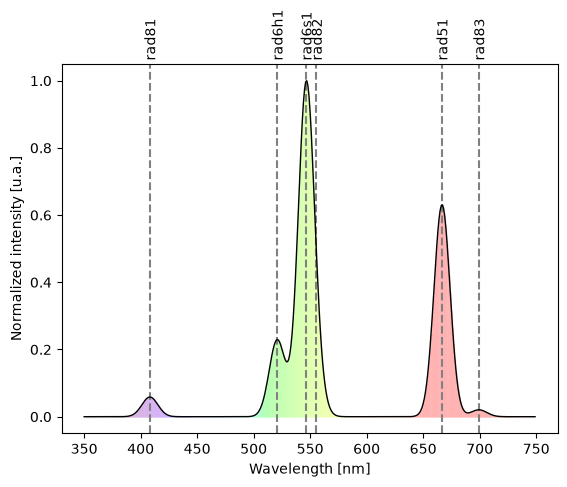

In [ ]:
sim1 = (
    Simulator(AndersonModelUnfolded())
    .with_transform(EmissionTransform(kind="emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-10, atol=1e-10))
    .with_values(
        {
            AndersonModelUnfolded.fs: 0.9,
            AndersonModelUnfolded.a_r: 0.9,
            AndersonModelUnfolded.energy_flux: 5 * u.W / u.cm**2,
        }
    )
    .with_post(post=LineEnergyPost())
)
ds = SteadyState().solve(sim1)
graph_spectra(ds,10)

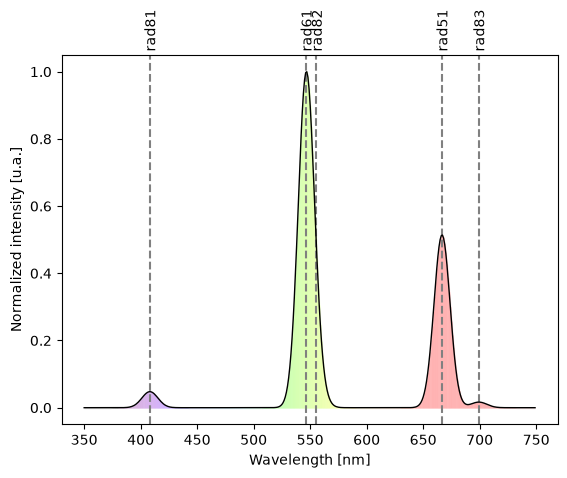

In [ ]:
sim2 = (
    Simulator(AndersonModel())
    .with_transform(EmissionTransform(kind="emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-10, atol=1e-10))
    .with_values(
        {
            AndersonModel.energy_flux: 5 * u.W / u.cm**2,
        }
    )
    .with_post(post=LineEnergyPost())
)
ds = SteadyState().solve(sim2)

graph_spectra(ds,10)

<Axes: xlabel='time'>

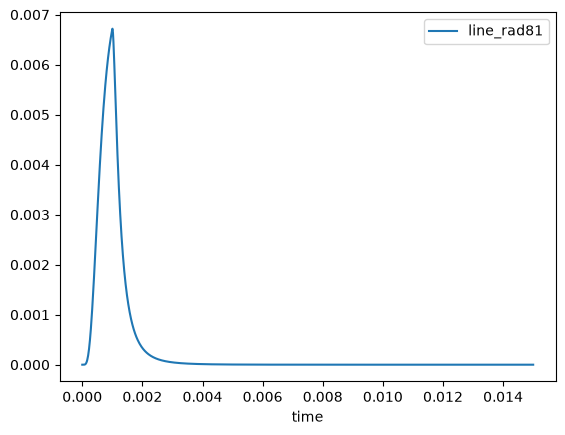

In [ ]:
from upconversion_models.jablonski_patch import PulsedExcitation
import numpy as np

pulse = PulsedExcitation(
    pulse_width=1e-3 * u.s,
    pulse_height=100 * u.W / u.cm**2,
    pump=AndersonModelUnfolded.energy_flux,
)

pulse.solve(
    sim1, save_at=np.linspace(0, 15e-3, 1000) * u.s
).pint.dequantify().to_dataframe()[['line_rad81']].plot()